1. INTROUDCTION
This project analyzes Chinook data. Chinook is a relational database data for a digital media store. Tools for this project include postgresql for database query, pandas for data extraction, matplotlib, seaborn and squarify for data visualization.

This project focuses on revenue generation. It studies the what genres and artists generates most revenues, the top buyers and top buying countries, as well as how revenue changes over time.

2. IMPORT AND CONNECTION

To connect to the data stored in postgresql locally, sqlalchemy is used. The database connection data is retrieved as environment variables using python-dotenv.

In [3]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import squarify as sqrf # for tree map

import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")


engine = create_engine(
    f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
)

print("Connected")

Connected


After loading the sql file of Chinook into postgresql, we have the following schematic diagram.


![Chinook Database Schema](img/chinook_schema.png)

In [4]:
# Testing the Display of a table
query = "SELECT * FROM artist LIMIT 5;" 

df = pd.read_sql(query, engine)

df

,artist_id,name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith
3,4,Alanis Morissette
4,5,Alice In Chains


3. Question 1: What are the top artists by revenue?

In [5]:
query_top_artist  = """select ar.artist_id,
ar.name,
 SUM(il.unit_price * il.quantity) as track_total_sales
from invoice_line il
join track t 
on il.track_id = t.track_id
join album al
on t.album_id = al.album_id
join artist ar 
on al.artist_id = ar.artist_id
group by ar.artist_id, ar.name
order by track_total_sales DESC;
"""

dfTopArtist= pd.read_sql(query_top_artist,engine)
#dfTopArtist
dfTopArtist.head(5)


,artist_id,name,track_total_sales
0,90,Iron Maiden,138.60
1,150,U2,105.93
2,50,Metallica,90.09
3,22,Led Zeppelin,86.13
4,149,Lost,81.59


In [6]:
Top5Sales= dfTopArtist["track_total_sales"].head(5).sum()
total = dfTopArtist["track_total_sales"].sum()

print(f"The Top 5 artists contribute {Top5Sales/total:.2%} of revenue.")

The Top 5 artists contribute 21.57% of revenue.


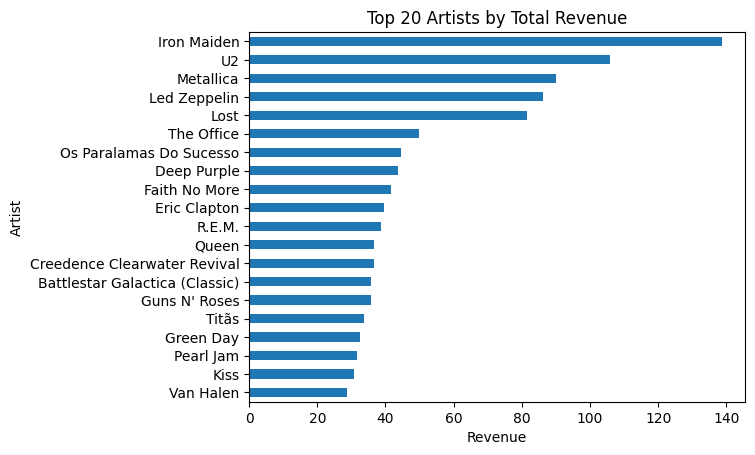

In [7]:
top20Artist = dfTopArtist.head(20)

top20Artist.plot(
    kind="barh",
    x="name",
    y="track_total_sales",
    legend=False
)

plt.title("Top 20 Artists by Total Revenue")
plt.xlabel("Revenue")
plt.ylabel("Artist")

plt.gca().invert_yaxis()   # highest revenue on top

plt.show()

Findings: 
- Iron Maiden generates the highest revenue (138.60) for Chinook, followed by U2 (105.93), Metallica (90.09), Led Zeppelin (86.13) and Lost	(81.59). These top 5 artists only contributes to 22% of shares.

4. Question 2: What are the best selling genres?

In [8]:
queryGenre = """
select g.genre_id,
g.name as Genre_name,
coalesce(SUM(il.unit_price * il.quantity),0) as revenue
from invoice_line il 
join track t 
on il.track_id = t.track_id 
right join genre g --to include genre even with no sale
on t.genre_id = g.genre_id 
group by g.genre_id, g.name
order by revenue DESC
"""

dfGenre = pd.read_sql(queryGenre, engine)
dfGenre

,genre_id,genre_name,revenue
0,1,Rock,826.65
1,7,Latin,382.14
2,3,Metal,261.36
3,4,Alternative & Punk,241.56
4,19,TV Shows,93.53
5,2,Jazz,79.20
6,6,Blues,60.39
7,21,Drama,57.71
8,14,R&B/Soul,40.59
9,24,Classical,40.59


In [9]:
#TOP 3 COUNTRIES REVENUE PERCENTAGE
total = dfGenre["revenue"].sum()
top5 = dfGenre["revenue"].head(5).sum()

top5_pcent = (top5 / total)

print(f"The top 5 genre comprises {top5_pcent:.2%} of total market revenue.")
print(f"The top genre is {dfGenre.iloc[0,1]}, totalling {dfGenre.iloc[0,2]/total:.2%}")
print(f"The second top genre is {dfGenre.iloc[1,1]}, totalling {dfGenre.iloc[1,2]/total:.2%}")

The top 5 genre comprises 77.52% of total market revenue.
The top genre is Rock, totalling 35.50%
The second top genre is Latin, totalling 16.41%


In [10]:
dfGenrePlot = dfGenre[
    dfGenre["revenue"].notna() &
    (dfGenre["revenue"] > 0)
].copy()

#To Present Genre Data on Treemap, including top 5 genres and others


dfGenreTop5 = dfGenrePlot.iloc[0:,1:].head(5)
other_genre_total = dfGenrePlot["revenue"].iloc[5:].sum()

#Create pd dataframe for GenreOther

dfOtherGenre = pd.DataFrame({
    "genre_name": ["Other"],
    "revenue": [other_genre_total]
})

#Concat dfGenreTop5 with dfOtherGenre
dfGenre5andOther= pd.concat([dfGenreTop5,dfOtherGenre],ignore_index=True)
dfGenre5andOther

,genre_name,revenue
0,Rock,826.65
1,Latin,382.14
2,Metal,261.36
3,Alternative & Punk,241.56
4,TV Shows,93.53
5,Other,523.36


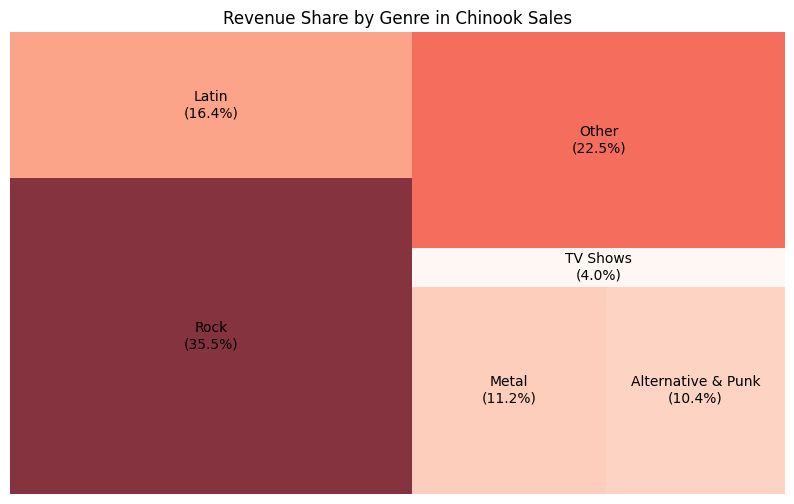

In [11]:
# data treatments for treemap
labels = dfGenre5andOther["genre_name"]
sizes = dfGenre5andOther["revenue"]
total= sum(sizes)
sizes_pcent = [f'{(val / total) * 100:.1f}%' for val in sizes] # Convert sizes from raw number to percentage

# create a color palette, mapped to these values
cmap = matplotlib.cm.Reds
mini=min(sizes)
maxi=max(sizes)
norm = matplotlib.colors.Normalize(vmin=mini, vmax=maxi)
colors = [cmap(norm(var)) for var in sizes]

plt.figure(figsize=(10, 6))

sqrf.plot(
    sizes=sizes,
    label = [f'{cat}\n({fig})' for cat, fig in zip(labels, sizes_pcent)],
    color=colors,
    alpha=0.8
)

plt.axis("off")
plt.title("Revenue Share by Genre in Chinook Sales")
plt.show()

Findings:
- Top genres are Rock, Latin, Metal, Alternative & Punk, and TV shows.
- Unlike artist revenue, genre revenue reveals that some genres are dominating the market. Of 25 genres, the top 5 genres generate 78% of total revenue. The top 5 artists combined revenue is only 22%. 


5. Question 3: Which countries generate the most revenue?

In [12]:
# Find the revenue of countries by grouping the data by billing_country,
#   summing up the invoice total of each country

queryCountry = """
SELECT billing_country,
       SUM(total) AS revenue
FROM invoice
GROUP BY billing_country
ORDER BY revenue DESC;
"""

dfCountry = pd.read_sql(queryCountry, engine)
dfCountry

,billing_country,revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


In [13]:
#TOP 3 COUNTRIES REVENUE PERCENTAGE
total = dfCountry["revenue"].sum()
top3 = dfCountry["revenue"].head(3).sum()

top3_pcent = (top3 / total)
print(f"The top 3 countries comprise {top3_pcent:.2%} of total market revenue.")

The top 3 countries comprise 43.89% of total market revenue.


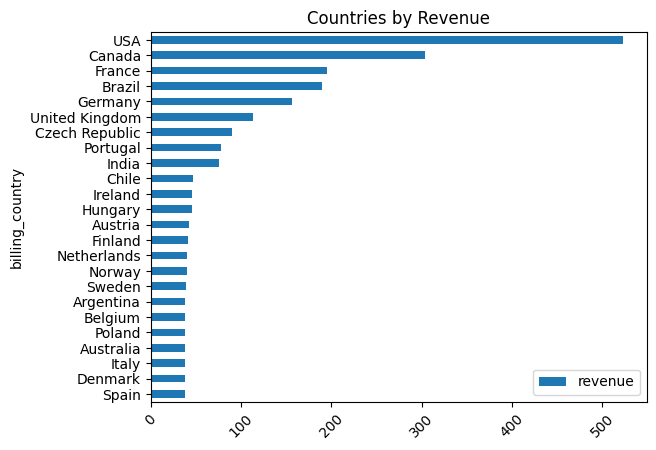

In [14]:
import matplotlib.pyplot as plt

dfCountry.plot(kind="barh", x="billing_country", y="revenue")
plt.title("Countries by Revenue")
plt.xticks(rotation=45)
plt.gca().invert_yaxis()
plt.show()

Findings:
- The top 3 countries are USA (523.06), Canada(303.96), and France (195.1). They comprise 44% of total market revenues.
- The market distribution across the world is relatively diversified. 
Other findings: 
- There are markets in South America (~8.16%), as well as India (~3.23%) but not Asia-Pacific, Middle-East or Africa.
- Canada has 60% of USA's revenue despite 10% of population.
 

6. Question 4: Which countries look strongest after normalizing revenue by customer and by invoice?

In [15]:
queryCountryCustomerInvoice = """
select billing_country, 
	sum(total) as revenue,
	sum(total) / count(distinct customer_id) as revenue_per_customer,
	sum(total) / count(invoice_id) as revenue_per_invoice,
	count(distinct customer_id) as customer_count,
	count(invoice_id) as invoice_count,
	count(invoice_id)::numeric / count(distinct customer_id) as invoice_per_customer
from invoice i
group by billing_country
order by revenue_per_customer desc;
"""
queryCountryCustomerInvoice = pd.read_sql(queryCountryCustomerInvoice,engine)
queryCountryCustomerInvoice

,billing_country,revenue,revenue_per_customer,revenue_per_invoice,customer_count,invoice_count,invoice_per_customer
0,Chile,46.62,46.620000,6.660000,1,7,7.0
1,Ireland,45.62,45.620000,6.517143,1,7,7.0
2,Hungary,45.62,45.620000,6.517143,1,7,7.0
3,Czech Republic,90.24,45.120000,6.445714,2,14,7.0
4,Austria,42.62,42.620000,6.088571,1,7,7.0
5,Finland,41.62,41.620000,5.945714,1,7,7.0
6,Netherlands,40.62,40.620000,5.802857,1,7,7.0
7,USA,523.06,40.235385,5.747912,13,91,7.0
8,Norway,39.62,39.620000,5.660000,1,7,7.0
9,Germany,156.48,39.120000,5.588571,4,28,7.0


- This query was done as I noticed although USA has 10 times the population of Canada, Canada generates 60% of revenue compared to the USA's. 
- To investigate whether it is caused by higher customer purchasing power, higher revenue per invoice, or higher customer base, I decided to obtain revenue of a country per customer (column 3), revenue of a country per invoice (column 4), and total customers of each country (column 5).

Findings:
- Turns out revenue per customer in Canada and revenue per invoice in Canada are smaller than those in the US. The disproportionate high revenue of Canada compared to the US was not caused by the purchasing power of customers.
- There are 13 and 8 customers in the USA and Canada respectively, so customer base in Canada drives the strong revenue.
- (Additionally, the data looks synthetic judging by low customer counts and customers of each country did 7 bills on average.)

7. Question 5: Who are the Top Buyers?

In [16]:
queryTopCustomer = """
select i.customer_id, 
	c.first_name,
	c.last_name,
	sum(i.total) as total_revenue,
	count(i.invoice_id) as total_invoices,
	sum(i.total) / count(i.invoice_id) as revenue_per_invoice
from invoice i
join customer c
on i.customer_id  = c.customer_id
group by i.customer_id, c.first_name, c.last_name
order by total_revenue desc;
"""

dfTopCustomer = pd.read_sql(queryTopCustomer, engine)
dfTopCustomer

,customer_id,first_name,last_name,total_revenue,total_invoices,revenue_per_invoice
0,6,Helena,Holý,49.62,7,7.088571
1,26,Richard,Cunningham,47.62,7,6.802857
2,57,Luis,Rojas,46.62,7,6.660000
3,45,Ladislav,Kovács,45.62,7,6.517143
4,46,Hugh,O'Reilly,45.62,7,6.517143
5,37,Fynn,Zimmermann,43.62,7,6.231429
6,24,Frank,Ralston,43.62,7,6.231429
7,28,Julia,Barnett,43.62,7,6.231429
8,7,Astrid,Gruber,42.62,7,6.088571
9,25,Victor,Stevens,42.62,7,6.088571


In [18]:
Top5CustSum= dfTopCustomer["total_revenue"].head(5).sum()
total = dfTopCustomer["total_revenue"].sum()
TopCustSum =dfTopCustomer["total_revenue"].max()
MedianCustRev = dfTopCustomer["total_revenue"].median()
AverageCustRev = dfTopCustomer["total_revenue"].mean()

print(f"The Top 5 customers contribute {Top5CustSum/total:.2%} of revenue.")
print(f"The average, median, and top revenues are {AverageCustRev:.2f}, {MedianCustRev} and {TopCustSum}.")

The Top 5 customers contribute 10.10% of revenue.
The average, median, and top revenues are 39.47, 37.62 and 49.62.


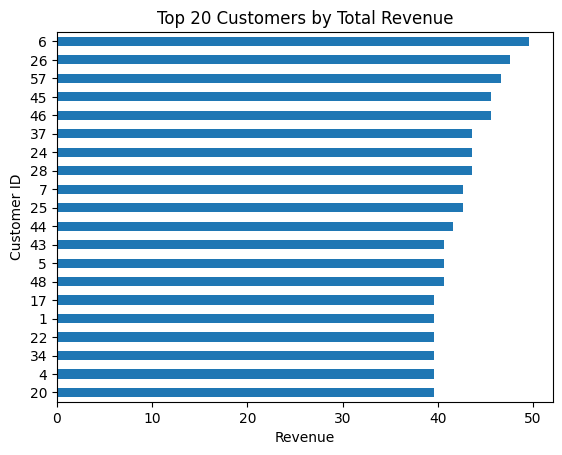

In [19]:
Top20Cust= dfTopCustomer.head(20)

Top20Cust.plot(
    kind="barh",
    x="customer_id",
    y="total_revenue",
    legend=False
)

plt.title("Top 20 Customers by Total Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()   # highest revenue on top

plt.show()

Findings for Customer Query:
- Revenues across each customer is relatively the same. No one is standing out. No key major buyers.
- Customer revenue is broadly distributed and only slightly right-skewed. Top 5 buyers only account for 10.10% revenue. 
- Each customer makes 7 transactions (except customer_id 59 having 6 invoices only), so total revenue contributions of each customer is driven by their basket sizes rather than their purchase frequencies.

8. Question 6: What do top buyers purchase?

In [20]:
# Something on DBeaver about favourite Genre, Artist, Album 
queryTop5BuyerFavGenre = """
select g.genre_id,
	g.name as musical_genre,
	SUM(il.unit_price * il.quantity) as total_revenue
from genre g
join track t 
	on g.genre_id = t.genre_id 
join invoice_line il 
	on il.track_id = t.track_id 
join invoice i
	on il.invoice_id = i.invoice_id
where i.customer_id  in (
	select i.customer_id
	from invoice i
	group by i.customer_id
	order by sum(i.total) desc
	limit 5)
group by g.genre_id, g.name
order by total_revenue desc;"""

dfTop5BuyerFavGenre = pd.read_sql(queryTop5BuyerFavGenre,engine)
dfTop5BuyerFavGenre

,genre_id,musical_genre,total_revenue
0,1,Rock,55.44
1,19,TV Shows,43.78
2,21,Drama,35.82
3,7,Latin,30.69
4,4,Alternative & Punk,18.81
5,3,Metal,12.87
6,14,R&B/Soul,6.93
7,18,Science Fiction,5.97
8,20,Sci Fi & Fantasy,5.97
9,6,Blues,5.94


In [21]:
queryTop5BuyerFavAlbum ="""
-- To find out most popular albums among 5 top customers
select a.album_id,
	a.title as album_title,
	SUM(il.unit_price * il.quantity) as total_revenue
from album a
join track t 
	on a.album_id = t.album_id
join invoice_line il 
	on il.track_id = t.track_id 
join invoice i
	on il.invoice_id = i.invoice_id
where i.customer_id  in (
	select i.customer_id
	from invoice i
	group by i.customer_id
	order by sum(i.total) desc
	limit 5)
group by a.album_id, a.title
order by total_revenue desc;
"""

dfTop5BuyerFavAlbum = pd.read_sql(queryTop5BuyerFavAlbum, engine)
dfTop5BuyerFavAlbum

,album_id,album_title,total_revenue
0,231,"Lost, Season 2",21.89
1,229,"Lost, Season 3",17.91
2,228,"Heroes, Season 1",15.92
3,230,"Lost, Season 1",13.93
4,227,"Battlestar Galactica, Season 3",11.94
...,...,...,...
65,82,The Colour And The Shape,0.99
66,238,The Best Of 1980-1990,0.99
67,235,How To Dismantle An Atomic Bomb,0.99
68,167,Acústico MTV,0.99


In [22]:
queryTop5BuyerFavArtist ="""select ar.artist_id,
	ar.name as artist,
	SUM(il.unit_price * il.quantity) as total_revenue
from artist ar 
join album a 
	on ar.artist_id = a.artist_id
join track t 
	on a.album_id = t.album_id
join invoice_line il 
	on il.track_id = t.track_id 
join invoice i
	on il.invoice_id = i.invoice_id
where i.customer_id  in (
	select i.customer_id
	from invoice i
	group by i.customer_id
	order by sum(i.total) desc
	limit 5)
group by ar.artist_id, ar.name
order by total_revenue desc;"""

dfTop5BuyerFavArtist = pd.read_sql(queryTop5BuyerFavArtist, engine)
dfTop5BuyerFavArtist

,artist_id,artist,total_revenue
0,149,Lost,53.73
1,150,U2,22.77
2,148,Heroes,15.92
3,147,Battlestar Galactica,11.94
4,88,Guns N' Roses,11.88
5,92,Jamiroquai,10.89
6,156,The Office,9.95
7,16,Caetano Veloso,5.94
8,18,Chico Science & Nação Zumbi,5.94
9,22,Led Zeppelin,5.94


Findings:
- For genres, top 5 buyers prefer Rock, TV Shows, Drama, Latin, Alternative & Punk.
- For albums, top 5 buyers in fact spend most on TV shows: Lost, Season 2, Lost, Season 3, Heroes, Season 1, Lost, Season 1, Battlestar Galactica, Season 3.
- For artists, top 5 buyers prefer Lost, U2, Heroes, Battlestar Galactica, Guns N' Roses.

9. Question 7: How does revenue change over time?

In [23]:
##Q7. TIME SERIES

querySalesPerQuarter = """
select
	extract(YEAR from invoice_date)::int as year_of_invoice,
    extract(quarter from invoice_date)::int as quarter_of_invoice,
    sum(total) as revenue,
	count(*) as quarterly_invoice_count,
    avg(total) as quarterly_average
from invoice
group by
	year_of_invoice,
    quarter_of_invoice
order by
    year_of_invoice,
    quarter_of_invoice;
"""

dfSalesPerQuarter = pd.read_sql(querySalesPerQuarter, engine)
dfSalesPerQuarter

,year_of_invoice,quarter_of_invoice,revenue,quarterly_invoice_count,quarterly_average
0,2021,1,110.88,20,5.544000
1,2021,2,112.86,21,5.374286
2,2021,3,112.86,21,5.374286
3,2021,4,112.86,21,5.374286
4,2022,1,143.86,21,6.850476
5,2022,2,112.86,21,5.374286
6,2022,3,111.87,20,5.593500
7,2022,4,112.86,21,5.374286
8,2023,1,112.86,21,5.374286
9,2023,2,144.86,21,6.898095


In [24]:
dfSalesPerQuarter[
    ["revenue", "quarterly_invoice_count", "quarterly_average"]
].corr(method="pearson")

,revenue,quarterly_invoice_count,quarterly_average
revenue,1.000000,0.338763,0.946622
quarterly_invoice_count,0.338763,1.000000,0.018191
quarterly_average,0.946622,0.018191,1.000000


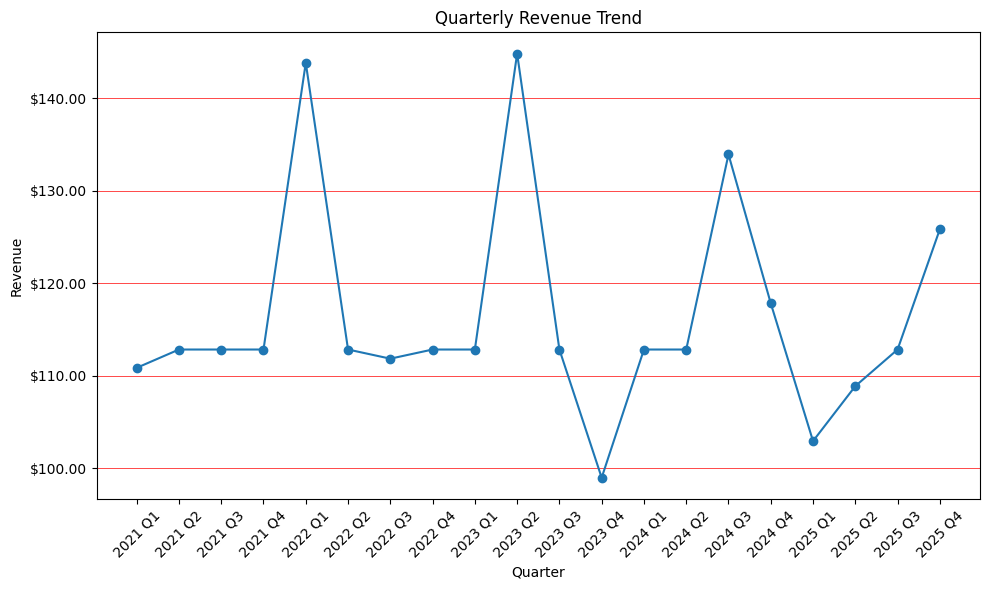

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

dfSalesPerQuarter["quarter_label"] = (
    dfSalesPerQuarter["year_of_invoice"].astype(str)
    + " Q"
    + dfSalesPerQuarter["quarter_of_invoice"].astype(str)
)

ax.plot(dfSalesPerQuarter["quarter_label"], dfSalesPerQuarter["revenue"], marker="o")
#ax.set_ylim(ymin=0)
ax.set_title("Quarterly Revenue Trend")
ax.set_xlabel("Quarter")
ax.set_ylabel("Revenue")

plt.grid(which='major', axis='y', color='r', linestyle='-', linewidth=0.5)
ax.yaxis.set_major_formatter('${x:.2f}') #set y-axis display as currency
plt.xticks(rotation=45)
plt.tight_layout()
plt.show(fig)

Question 7 Findings:
- Quarterly revenue fluctuates around low $110, with isolated spikes
- No strong upward or downward trends
- Spikes are shown on the plot. High pearson correlation between revenue and quarterly average (r = 0.947) while low correlation between revenue and quarterly invoice count (r = 0.339). This indicates the quarterly revenue spikes was driven by larger average invoice total rather than higher counts of transactions.

10. Summary

The analysis revealed that the revenues were dominated by several genres. Top 5 genres alone generates 78% of revenue, with Rock being the strongest genre by revenue. On the other hand, revenues were not much dominated by artists as top 5 artists contribute to 22% of revenue.

Country analysis indicates that the top 3 markets are USA, Canada, and France. Customer-level analysis indicates that the buying contributions across buyers were broadly distributed, meaning that revenue is not much dependent on a certain buyer.

Time-series analysis shows that there are isolates spikes across the stable quartely revenue. The spikes are highly correlated to invoice totals and lowly correlated to invoice count, implying that spikes were driven by total revenue in each bill rather than higher amounts of bills.

Several limitations of the chinook dataset: 
1. it is a synthetic set. e.g. in invoice_line, it is found that invoice_id and track_id move increasingly down the table. Customers did 7 transactions each (except one of did 6). Pricing of tracks were uniform.
2. The customer base in each country is too small to be normalized. Many countries have only 1 buyer. Not much conclusions about customer preferences can be drawn from small size.